## PEFT 모델 튜닝 실습
PEFT(Parameterized Efficient Fine-Tuning)는 최신 AI 모델(LLM, 생성형 AI 등)을 데이터와 환경에 맞게 경량 파인튜닝할 수 있는 방법이다.

# PEFT(파라미터 효율적 파인튜닝)

**PEFT**는 기존 모델의 모든 파라미터를 학습하지 않고,  
일부 **경량화된 파라미터(예: Adapter, Prefix-Tuning, LoRA 등)** 만 조정하여  
빠르고 효율적으로 학습하는 방법을 말한다.

---

## LoRA란? (Low-Rank Adaptation)

- **개념**: 모델의 큰 가중치 행렬을 건드리지 않고,  
  그 옆에 **저차원 행렬(작은 길)** 을 추가하여 학습하는 방식  
- **비유**:  
  원래 있던 큰 길(기존 가중치)은 그대로 두고,  
  그 옆에 **작은 보조 도로(LoRA 경로)** 를 만들어 이 길만 학습하는 것과 같다.  
- **장점**:  
  - 기존 모델 전체를 학습하지 않으므로 **메모리와 연산량 절약**  
  - 큰 모델도 **가볍고 효율적으로 학습 가능**  
  - 최근 가장 널리 쓰이는 PEFT 기법이다.

---
<br>

## 이번 실습의 목표

1. 이번 실습에서는 **LoRA 방식**을 적용해 볼 것이다.  
   즉, 기존 모델을 그대로 두고,  
   **LoRA가 추가하는 작은 파라미터만 학습**시켜  
   모델이 새로운 데이터에 적응하는 과정을 학습할 것이다. <br>
   그런데 그냥 LoRA가 아니라 <br>
   바로 양자화된 모델로 실습할 것이다.
   
2. 허깅페이스의 API를 적극적으로 활용해 본다.



## 1. 환경 설정 및 라이브러리 설치

이 단계에서는 필요한 라이브러리를 설치하고, Colab 런타임을 T4 GPU로 설정한다.

In [1]:
# Step1 : 라이브러리 설치
# 1. Colab 런타임: GPU(T4) 선택 권장
# 2. pip로 필요한 패키지 설치

!pip install -q transformers peft datasets accelerate bitsandbytes

from transformers import logging
logging.set_verbosity_error()

 **코드 설명:**
- `transformers`: 허깅페이스에서 모델과 토크나이저를 불러오는 라이브러리
- `peft`: 허깅페이스에서 제공하는 Adapter, LoRA, Prefix Tuning 등 경량 파인튜닝을 위한 라이브러리
- `datasets`: 허깅페이스의 오픈데이터셋 로딩할때 사용
- `accelerate`: 저사양 GPU 환경에서 분산학습을 설정할 수 있게 하는 라이브러리
- `bitsandbytes`: 대형 모델의 파라미터를 8 또는 4-bit 양자화(Quantization)해서 GPU 사용량 줄여주는 라이브러리 (meta 연구원이 만든것)

## 2. 실습용 예제 데이터 만들기

In [2]:
# Step2 : 데이터 준비
# 작은 샘플 데이터로 실습 가능하므로 Q&A, 텍스트 요약 등 자유롭게 구성해 보았다.

from datasets import Dataset

data = [
    {"instruction": "Tell me today's weather", "output": "Today it is sunny with a temperature of 25 degrees."},
    {"instruction": "What is the population of Seoul?", "output": "The population of Seoul is about 9.6 million."},
    {"instruction": "Who is a good SSAFY instructor for the Python track?", "output": "The best instructor for the Python track is Min-ho Choi from Mincoding."},
    {"instruction": "What is today's lunch menu?", "output": "Today's lunch menu includes yangjangpi, spicy pepper japchae, and a glass of Wuliangye, a premium Chinese liquor."},
    {"instruction": "Translate 'Hello' into Korean", "output": "The translation of 'Hello' in Korean is '안녕하세요'."},
    {"instruction": "What is the capital of Japan?", "output": "The capital of Japan is Tokyo."},
    {"instruction": "Summarize: 'Artificial Intelligence is changing the world in many industries such as healthcare, finance, and education.'",
     "output": "AI is transforming healthcare, finance, and education."},
    {"instruction": "What is 5 plus 7?", "output": "5 plus 7 equals 12."},
    {"instruction": "Write a short greeting for a friend", "output": "Hey! How have you been? Hope everything is going well."},
    {"instruction": "Name three countries in Southeast Asia", "output": "Three countries in Southeast Asia are Thailand, Vietnam, and Malaysia."},
    {"instruction": "What is the largest planet in our solar system?", "output": "The largest planet in our solar system is Jupiter."},
]

dataset = Dataset.from_list(data)

## 3. 사전학습 모델 불러오기 (4-bit 양자화)

오늘 peft 실습할 모델은 meta의 facebook/opt-350m 모델로 준비 했습니다.
모델크기가 0.35B 정도 되서 실습환경에 좋다고 판단했고, Meta가 공개한 GPT계열의 모델로 오픈소스라서 선택했습니다.

In [5]:
# Step3 : 모델 준비

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch
model_name = "facebook/opt-350m"

# 4-bit 양자화 셋팅 설정

# 기존 pretrained 모델의 파라미터에 양자화를 적용하는것!!!
# 기존 파라미터의 weight를 4bit로 바꿔서 GPU메모리에 저장 (학습할 것이 아니니까!)
# 새로 추가되는 파라미터는 16bit로 연산한것임

# 이미 만들어진 모델을 메모리에 올릴 때 4bit로 압축해서 불러오는 과정
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # 모델을 4bit로 로드 (원래는 32bit 모델임)
    bnb_4bit_compute_dtype=torch.float16, # 실제 연산 시에는 float16으로 계산, 따라서 저장은 4bit 연산은 16bit 할꺼임
    bnb_4bit_quant_type="nf4", # 양자화 방식은 Normal Float 4-bit 하겠다.
    bnb_4bit_use_double_quant=True # 메모리에 저장되는 파리미터의 양자화 압축을 더블로 하겠다
                                   # float32 → 4bit 한번해서 모델의 가중치 4bit로 저장하고
                                   # 가중치를 4bit로 바꾸는데 곱해지는 스케일값도 4bit로 바꾸는 작업
)

# 토크나이저
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 모델 로드
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto" # vram 모자라면 알아서 cpu써라
)
# 모델 구조 확인
model

config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/663M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/662M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

OPTForCausalLM(
  (model): OPTModel(
    (decoder): OPTDecoder(
      (embed_tokens): Embedding(50272, 512, padding_idx=1)
      (embed_positions): OPTLearnedPositionalEmbedding(2050, 1024)
      (project_out): Linear4bit(in_features=1024, out_features=512, bias=False)
      (project_in): Linear4bit(in_features=512, out_features=1024, bias=False)
      (layers): ModuleList(
        (0-23): 24 x OPTDecoderLayer(
          (self_attn): OPTAttention(
            (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
          )
          (activation_fn): ReLU()
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear4bit(in_features=1024, out_features=4096, bias=True)
          (

### 3.1 모델과 토크나이저 로드 (코드 설명)

#### 사전학습 모델 지정
- **model_name**: "facebook/opt-350m"  
- 소규모 OPT 모델로, 실습용으로 적합

#### 4-bit 양자화 설정
- 숫자 표현을 줄여 메모리 절약, 저사양 GPU에서도 실행 가능  
- `load_in_4bit=True`: 모델 파라미터를 4-bit로 줄임  
- `bnb_4bit_compute_dtype="float16"`: 계산 시 사용하는 데이터 타입  
- `bnb_4bit_quant_type="nf4"`: 양자화 방식  
- `bnb_4bit_use_double_quant=True`: 안정성을 위해 2단계 양자화

#### 토크나이저 로드
- 텍스트 → 모델이 이해 가능한 숫자 ID 변환  
- `AutoTokenizer.from_pretrained(model_name)`: 모델에 최적화된 토크나이저 자동 로드

#### 모델 로드
- 사전학습된 OPT 모델 로딩 후
- `quantization_config=bnb_config`: 위에서 설정한 4-bit 양자화 적용  
- `device_map="auto"`: GPU가 있으면 GPU에, 없으면 CPU에 자동 배치


## 4. PEFT(LoRA) 설정 및 적용

### 4.1 LoRA 개념 요약
- **LoRA**: 기존 모델 파라미터 고정시키고 옆에 **작은 저차원 행렬**(LoRA 모듈)만 학습
  - 기존 모델의 특정 레이어에 작은 저차원 행렬(LoRA 모듈)을 추가하고, 그 추가된 행렬의 가중치만 업데이트한다.
  - 원래 있던 가중치 W (예를들면 q_proj, v_proj)에 저차원 행렬 A, B를 곱해 만든 보정값(델타W)를 붙인다음, W는 고정시켜 놓고 델타W만 학습시킨다.
  - 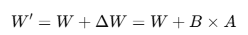

- 장점: 학습 파라미터 수 ↓, 메모리·시간·비용 ↓



In [6]:
# Step4 : LoRA 실습을 위한 PEFT 설정이다.

from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    task_type="CAUSAL_LM",  # 생성 작업
    r=8,                     # LoRA 랭크
    lora_alpha=16,          # 학습 영향력 크기
    lora_dropout=0.1        # 과적합 방지 비율
    #target_modules=["q_proj", "v_proj"] # 생략가능 - Hugging Face의 PEFT 라이브러리가 모델의 타입과 구조를 스캔해서 LoRA붙이기 좋은 Linear 레이어를 자동선택 합니다.
)

# 기존 모델에 LoRA 적용
model = get_peft_model(model, lora_config)

# 학습 가능한 파라미터 수 확인
model.print_trainable_parameters()



trainable params: 786,432 || all params: 331,982,848 || trainable%: 0.2369


### PEFT / LoRA 설정

#### 1. peft 라이브러리
-  파라미터 효율적 파인튜닝(PEFT)을 쉽게 구현하기 위해 Huggingface의 `peft` 모듈 사용

#### 2. LoraConfig
-  LoRA 방식(경량 파인튜닝 모델)을 위한 세부 설정 값  
- `task_type="CAUSAL_LM"`: 텍스트 생성(LLM) 작업용 설정, LLaMA나 GPT와 같은 디코더 only 모델은 모두 CAUSAL_LM 입니다.
- `r=8`: LoRA의 랭크, '새로 만드는 얇은 길'의 크기. 값이 작을수록 더 경량화, 더해지는 저차원 행렬의 크기를 말하며, 보통 r=4~16 사이가 많이 쓰이고, QLoRA 할때는 r=8 값으로 많이 사용합니다.
- `lora_alpha=16`: LoRA 적용 강도, 학습 신호의 세기 조절해서 얼마나 최종 모델에 강하게 또는 약하게 반영할지 크기를 조절 (8~32 정도의 값을 일반적으로 가짐)
- `lora_dropout=0.1`: 과적합 방지, 학습 중 일부 LoRA 경로를 임의로 끔  

#### 3. get_peft_model
- 기존 모델에 LoRA 설정을 적용  
- 모델 전체가 아니라 LoRA 부위만 학습 가능  
- 큰 모델도 적은 메모리로 효율적 파인튜닝 가능

#### 4. model.print_trainable_parameters()
- 실제 학습 가능한 파라미터 수를 확인  
- LoRA로 학습되는 파라미터가 매우 적음을 시각적으로 확인한다.


## 5. 모델 학습(파인튜닝)

In [5]:
# Step5 : 학습하기 (허길페이스 에서 제공해주는 라이브 러리 사용해보기)
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

# 데이터 전처리 함수 : 토큰화 함수
# chat 템플릿 구조가 없는 일반 언어모델인 opt-350m은 한 문장 형태의 텍스트 시퀀스로 이어붙여서 학습해야 함 (모델마다 달라요)
# # texts = [
#     "What is the population of Seoul?\nIt is about 9.4 million.",
#     "What is the weather today?\nIt is sunny today."
# ]

def tokenize(batch):
    texts = [ins + "\n" + out for ins, out in zip(batch["instruction"], batch["output"])]
    return tokenizer(texts, truncation=True, padding="max_length", max_length=128)

# 데이터셋 전처리
tokenized_dataset = dataset.map(tokenize, batched=True) # 배치사이즈 자동조절(학습에 알아서 최적화함)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# 학습 설정
training_args = TrainingArguments(
    per_device_train_batch_size=1,
    max_steps=1000,         # 시연용 짧게 설정
    learning_rate=2e-4,    # LoRA 국룰
    logging_steps=10,
    output_dir="./lora_output",
    fp16=True,
    report_to="none"   # Hugging Face의 Trainer는 단순히 모델을 학습시키는 것뿐만 아니라, 훈련 과정에 대한 정보를 자동으로 기록하는 데 이 옵션을 꺼야한다.
)

# Trainer 생성 및 학습 시작
trainer = Trainer(
    model=model,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
    args=training_args

)
trainer.train()

print("학습끝!")
trainer.save_model("./lora_output/final_model") # LoRA 파라미터만 모아서 따로 저장




# from torch.utils.data import DataLoader
# from torch.optim import AdamW
# from transformers import get_scheduler
# from tqdm import tqdm
# import torch


# train_dataloader = DataLoader(tokenized_dataset, batch_size=1, shuffle=True)

# optimizer = AdamW(model.parameters(), lr=2e-4)

# num_epochs = 3
# num_training_steps = len(train_dataloader) * num_epochs
# scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps) #학습률조절

# model.train()
# for epoch in range(num_epochs):
#     progress_bar = tqdm(enumerate(train_dataloader), total=len(train_dataloader))
#     for step, batch in progress_bar:
#         batch = {k: v.to(model.device) for k, v in batch.items()}  # GPU로 이동

#         with torch.cuda.amp.autocast():  # FP16 훈련
#             outputs = model(**batch)
#             loss = outputs.loss

#         loss.backward()
#         optimizer.step()
#         scheduler.step()
#         optimizer.zero_grad()

#         if step % 10 == 0:  # 로그 출력
#             progress_bar.set_description(f"Epoch {epoch} Step {step} Loss {loss.item():.4f}")


# print("학습끝!")
# torch.save(model.state_dict(), "model_final.pth")


Map:   0%|          | 0/11 [00:00<?, ? examples/s]

{'loss': '2.863', 'grad_norm': '5.084', 'learning_rate': '0.0001986', 'epoch': '0.9091'}
{'loss': '2.628', 'grad_norm': '6.158', 'learning_rate': '0.0001966', 'epoch': '1.818'}
{'loss': '2.304', 'grad_norm': '7.435', 'learning_rate': '0.0001948', 'epoch': '2.727'}
{'loss': '1.838', 'grad_norm': '9.275', 'learning_rate': '0.0001932', 'epoch': '3.636'}
{'loss': '2.215', 'grad_norm': '6.987', 'learning_rate': '0.0001912', 'epoch': '4.545'}
{'loss': '1.163', 'grad_norm': '7.884', 'learning_rate': '0.0001892', 'epoch': '5.455'}
{'loss': '2.015', 'grad_norm': '16.61', 'learning_rate': '0.0001872', 'epoch': '6.364'}
{'loss': '1.093', 'grad_norm': '7.72', 'learning_rate': '0.0001852', 'epoch': '7.273'}
{'loss': '1.55', 'grad_norm': '12.86', 'learning_rate': '0.0001832', 'epoch': '8.182'}
{'loss': '1.052', 'grad_norm': '9.281', 'learning_rate': '0.0001812', 'epoch': '9.091'}
{'loss': '1.355', 'grad_norm': '9.689', 'learning_rate': '0.0001792', 'epoch': '10'}
{'loss': '1.149', 'grad_norm': '10.4

- def tokenize(batch): 데이터 전처리를 위한 함수에요.
   - 데이터셋에는
     - "instruction": 모델에 입력할 질문 또는 명령
     - "output": 정답 또는 모델이 생성하길 원하는 문장 이렇게 되어 있는데
     - instruction + "\n" + output 형식으로 하나의 문장으로 만들어서 학습시킬껍니다.
   - 옵션에 대한 설명이에요.
     - truncation=True: 최대 길이를 넘으면 자름
     - padding="max_length": 길이가 짧은 문장은 PAD 토큰으로 채움
     - max_length=128: 문장의 최대 토큰 길이 (보통은 512~1024 등으로 많이 사용해요)
    
- DataCollatorForLanguageModeling : 배치(batch)를 구성해주는 객체
  - mlm=False: 마스크드 언어모델(BERT형)이 아닌, Causal LM(GPT형) 학습 방식으로 동작
  - per_device_train_batch_size=1  : GPU 1개당 배치 크기 (VRAM 절약용)
  - max_steps=200                  : 총 학습 스텝 수 (시연용, 빠르게 종료)
  - learning_rate=2e-4             : 학습률, LoRA/QLoRA에서 자주 사용하는 값
  - logging_steps=10               : 10스텝마다 손실 로그 출력하라
  - output_dir="./lora_output"     : 학습할때 파라미터를 저장하는 경로
  - fp16=True                      : 16비트 정밀도 학습 (속도 향상 + VRAM 절약)


**손실(Loss)** 감소 추이를 확인하자. LoRA 모듈만 학습되고 있다는 점을 확인하자.

## 자 이제 추론해 볼까요?

In [6]:

from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_name = "facebook/opt-350m"

# 4bit 양자화 설정 (PEFT 전 모델도 동일 조건으로 로드)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

# 토크나이저
tokenizer = AutoTokenizer.from_pretrained(model_name)

# ------------------------------
# 1) PEFT 적용 전 (기본 모델)
# ------------------------------
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

# 허깅페이스 API 사용!!
# pipline()은 입력 텍스트만 주면 알아서 토크나이즈 → 모델 처리 → 결과 해석까지 다 해주는 라이브러리에요. (transformers에 포함)
pipe_base = pipeline("text-generation", model=base_model, tokenizer=tokenizer, device_map="auto")

print("=== PEFT 적용 전 결과 ===")
print(pipe_base("What is the population of Seoul?", max_new_tokens=20)[0]["generated_text"])
print(pipe_base("What is the weather today?", max_new_tokens=20)[0]["generated_text"])


# ------------------------------
# 2) PEFT 적용 후 (LoRA 학습 모델)
# ------------------------------
pipe_peft = pipeline("text-generation", model=model, tokenizer=tokenizer, device_map="auto")

print("\n=== PEFT 적용 후 결과 ===")
# print(pipe_peft("What is the population of Seoul?", max_new_tokens=20)[0]["generated_text"])
print(pipe_peft("What is the population of Seoul?", max_new_tokens=20,repetition_penalty=1.5)[0]["generated_text"])
print(pipe_peft("What is the weather today?", max_new_tokens=20)[0]["generated_text"])


Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

=== PEFT 적용 전 결과 ===
What is the population of Seoul?
A total of 20,000,000 people, including over 6,000,000 Koreans,
What is the weather today?
The sky is cloudy today and the temperatures are expected to remain cooler.
But are you going

=== PEFT 적용 후 결과 ===
What is the population of Seoul?
The population of Korea has increased from about 9.6 million to 13.7 m in April
What is the weather today?
The weather today is sunny with a temperature of 25 degrees. TheVA is 14.6%


### 허깅페이스에서 제공하는 api 중 pipeline 예시에요.

In [7]:
# from transformers import pipeline

# generator = pipeline("text-generation", model="facebook/opt-350m")
# print(generator("hello good to see you bro"))


In [8]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
# from peft import PeftModel
# adapter_path = "./lora_output/final_model"

model_name = "facebook/opt-350m"

# 4bit 양자화 설정
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

# 토크나이저와 모델 로드
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)
# model = PeftModel.from_pretrained(base_model, adapter_path)

# pipeline() 없이 직접 실행하는 방식

# 입력 텍스트를 토크나이즈
prompt = "What is the population of Seoul?"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# 모델에 입력하여 토큰 생성
with torch.no_grad():  # 학습 아님 → 그래디언트 계산 비활성화
    outputs = model.generate(
        **inputs,               # 모델에 입력
        max_new_tokens=50,      # 새로 생성할 토큰 수
        temperature=0.8,        # 창의성 정도
        top_p=0.9,              # 상위 확률 토큰만 선택
        do_sample=True          # 샘플링 활성화 (랜덤성 추가)
    )

# 생성된 토큰을 디코딩 (숫자 → 텍스트)
result = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(result)

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

What is the population of Seoul? I'm not sure how much more people there would be if they were more populated.
I think the population is around 2 million.


## 마무리 및 중요 포인트

이번 실습을 통해 우리는 **LoRA(저차원 적응 학습)** 방식으로 모델을 파인튜닝하는 과정을 경험했다.

### 핵심 요약
- **LoRA는 기존 모델 파라미터를 그대로 두고**,  
  작은 저차원 행렬만 학습하여 새로운 작업에 적응시킨다.
- **효율적 학습**: 전체 모델을 학습하지 않으므로 **메모리와 연산량 절약**이 가능하다.
- **빠른 적응**: 기존 모델의 일반 지식을 유지하면서 새로운 데이터에 빠르게 적응할 수 있다.

### 기억할 점
1. **기존 가중치는 수정하지 않는다**: LoRA는 보조 경로만 학습하므로 원본 모델은 그대로 유지된다.  
2. **작은 파라미터 학습**: 학습 속도가 빠르고, GPU 메모리 부담이 적다.  
3. **적절한 저차원 크기 선택**: LoRA 행렬 차원이 너무 작으면 학습 효과가 제한되고, 너무 크면 효율이 떨어진다.  
4. **원본 모델 호환성**: LoRA는 대부분의 사전학습 모델에 적용 가능하지만, 모델 구조를 잘 확인하고 적용해야 한다.

이번 실습을 통해, 우리는 **경량화된 파라미터만 조정해도 모델이 새로운 작업을 충분히 학습할 수 있음**을 확인했다.
앞으로 실제 프로젝트에서 **빠르고 효율적인 파인튜닝 전략**으로 LoRA를 적극 활용할 수 있을 것이다.
